In [1]:
import os
os.chdir(r"D:\Joseph\Projects\kg-default-of-credit-cards")
print(os.getcwd())

D:\Joseph\Projects\kg-default-of-credit-cards


In [2]:
from pkg_credit_default.utils.logger            import logger
from pkg_credit_default.config.config_loader    import load_config
from pkg_credit_default.utils.utils             import load_ml_model
from pkg_credit_default.modeling.evaluator      import evaluate_model
import pandas as pd

# load the ml (e.g. champion) model and its metrics
config = load_config()
model_path = config["paths"]["output_dir_models"] + "/20260602_111120_champion_logistic_regression/" + "champion_logistic_regression_model.pkl"
champion_model = load_ml_model(model_path=model_path)
print(f"Champion model: {champion_model}") 
    
# evaluate the champion model on the test set (if needed)
test_data_path = config["paths"]["output_dir_data"] + "/test.csv"
test_df = pd.read_csv(test_data_path)
X_test = test_df.drop(columns=["target"])
y_test = test_df["target"]
test = evaluate_model(champion_model[1]["model"], X_test, y_test)

#evaluate the champion model on the training set (if needed)
train_data_path = config["paths"]["output_dir_data"] + "/train.csv"
train_df = pd.read_csv(train_data_path)
X_train = train_df.drop(columns=["target"])
y_train = train_df["target"]
train = evaluate_model(champion_model[1]["model"], X_train, y_train)

#Write in tabular format and print the results of the evaluation metrics for both train and test sets
results_df = pd.DataFrame({
    "dataset": ["train", "test"],
    "accuracy": [train["accuracy"], test["accuracy"]],
    "precision": [train["precision"], test["precision"]],
    "recall": [train["recall"], test["recall"]],
    "f1_score": [train["f1_score"], test["f1_score"]],
    "roc_auc": [train["roc_auc"], test["roc_auc"]]
})
print(results_df)

2026-06-19 21:09:25,030 - CREDIT_CARDS_DEFAULT - INFO - load_config() - Starting to load configuration...
2026-06-19 21:09:25,032 - CREDIT_CARDS_DEFAULT - INFO - _load_yaml() - Loading YAML configuration from: configs\base\base.yaml
2026-06-19 21:09:25,036 - CREDIT_CARDS_DEFAULT - INFO - _load_yaml() - Loading YAML configuration from: configs\dev\training.yaml
2026-06-19 21:09:25,051 - CREDIT_CARDS_DEFAULT - INFO - load_config() - Configuration loaded successfully.


c:\Users\josep\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


2026-06-19 21:09:45,074 - CREDIT_CARDS_DEFAULT - INFO - load_config() - Starting to load configuration...
2026-06-19 21:09:45,080 - CREDIT_CARDS_DEFAULT - INFO - _load_yaml() - Loading YAML configuration from: configs\base\base.yaml
2026-06-19 21:09:45,082 - CREDIT_CARDS_DEFAULT - INFO - _load_yaml() - Loading YAML configuration from: configs\dev\training.yaml
2026-06-19 21:09:45,094 - CREDIT_CARDS_DEFAULT - INFO - load_config() - Configuration loaded successfully.
2026-06-19 21:09:45,094 - CREDIT_CARDS_DEFAULT - INFO - Loading model and its metrics...
Champion model: ('logistic_regression', {'model': Pipeline(memory=Memory(location=cache/sklearn\joblib),
         steps=[('feature_engineering', FeatureEngineering()),
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(C=0.1, class_weight='balanced',
                                    max_iter=1000, penalty='l1',
     

In [3]:
print(test)

{'accuracy': 0.7716666666666666, 'precision': 0.48140900195694714, 'recall': 0.5620715917745621, 'f1_score': 0.5186226282501757, 'roc_auc': 0.7453399243520225, 'y_pred': array([0, 0, 0, ..., 0, 1, 0], shape=(6000,)), 'y_proba': array([0.41653561, 0.3541239 , 0.39973293, ..., 0.43460634, 0.72719582,
       0.29427578], shape=(6000,))}


CONFUSION MATRIX

In [4]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, test["y_pred"])
print("Confusion Matr ix:")
print(cm)

Confusion Matr ix:
[[3892  795]
 [ 575  738]]


CLASSIFICATION THRESHOLD

In [5]:
# Use different thresholds to evaluate the model performance
thresholds = [0.3, 0.4, 0.6, 0.5, 0.7]

for threshold in thresholds:
    print(f"Evaluating model with threshold: {threshold}")
    y_pred_threshold = (test["y_proba"] >= threshold).astype(int)
    cm_threshold = confusion_matrix(y_test, y_pred_threshold)
    print(f"Confusion Matrix at threshold {threshold}:")
    print(cm_threshold)
 
from sklearn.metrics import precision_score, recall_score
# Compare the recall and precision at different thresholds
for threshold in thresholds:
    y_pred_threshold = (test["y_proba"] >= threshold).astype(int)
    precision_threshold = precision_score(y_test, y_pred_threshold)
    recall_threshold = recall_score(y_test, y_pred_threshold)
    print(f"Threshold: {threshold}, Precision: {precision_threshold}, Recall: {recall_threshold}")

Evaluating model with threshold: 0.3
Confusion Matrix at threshold 0.3:
[[1072 3615]
 [ 106 1207]]
Evaluating model with threshold: 0.4
Confusion Matrix at threshold 0.4:
[[2929 1758]
 [ 345  968]]
Evaluating model with threshold: 0.6
Confusion Matrix at threshold 0.6:
[[4039  648]
 [ 644  669]]
Evaluating model with threshold: 0.5
Confusion Matrix at threshold 0.5:
[[3892  795]
 [ 575  738]]
Evaluating model with threshold: 0.7
Confusion Matrix at threshold 0.7:
[[4219  468]
 [ 742  571]]
Threshold: 0.3, Precision: 0.25031107424305266, Recall: 0.9192688499619193
Threshold: 0.4, Precision: 0.35509904622157007, Recall: 0.7372429550647372
Threshold: 0.6, Precision: 0.5079726651480638, Recall: 0.5095201827875095
Threshold: 0.5, Precision: 0.48140900195694714, Recall: 0.5620715917745621
Threshold: 0.7, Precision: 0.5495668912415784, Recall: 0.43488194973343486


0.5 Threshold is reasonable.

FEATURE IMPORTANCE

In [18]:
# Logistic regression model
model_name, model_info = champion_model
pipeline = model_info["model"]
logistic_model = pipeline.named_steps["model"]
print(logistic_model.coef_)
print(type(logistic_model))

print(len(X_train.columns))
print(len(logistic_model.coef_[0]))

[[-0.21573422 -0.06690594 -0.04113127 -0.06788249  0.06481555 -0.22473186
   0.05999486  0.14648623  0.10785331  0.0382106   0.02926538  0.
   0.00120456  0.05512368 -0.01415707 -0.00254586  0.         -0.12555252
  -0.2171505  -0.0241612  -0.03796812 -0.00499531 -0.0350941   0.
  -0.00121701  0.79620852]]
<class 'sklearn.linear_model._logistic.LogisticRegression'>
23
26


In [ ]:
pipeline = champion_model[1]["model"]
pipeline_steps = pipeline.named_steps["model"]

# get transformed data
X_trans = pipeline[:-1].transform(X_train)
feature_names = [f"f{i}" for i in range(X_trans.shape[1])]

coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": pipeline_steps.coef_[0]
})
print(coef_df.sort_values(by="coefficient", key=abs, ascending=False))

2026-06-07 22:00:29,454 - CREDIT_CARDS_DEFAULT - INFO - Calculating average balance over the last 6 months...
2026-06-07 22:00:29,469 - CREDIT_CARDS_DEFAULT - INFO - Calculating credit utilization...
2026-06-07 22:00:29,473 - CREDIT_CARDS_DEFAULT - INFO - Calculating late payment indicator for M1...
   feature  coefficient
25     f25     0.796209
5       f5    -0.224732
18     f18    -0.217151
0       f0    -0.215734
7       f7     0.146486
17     f17    -0.125553
8       f8     0.107853
3       f3    -0.067882
1       f1    -0.066906
4       f4     0.064816
6       f6     0.059995
13     f13     0.055124
2       f2    -0.041131
9       f9     0.038211
20     f20    -0.037968
22     f22    -0.035094
10     f10     0.029265
19     f19    -0.024161
14     f14    -0.014157
21     f21    -0.004995
15     f15    -0.002546
24     f24    -0.001217
12     f12     0.001205
11     f11     0.000000
16     f16     0.000000
23     f23     0.000000


### SHAP EXPLAINER

{'feature_engineering': FeatureEngineering(), 'imputer': SimpleImputer(strategy='median'), 'scaler': StandardScaler(), 'model': LogisticRegression(C=0.1, class_weight='balanced', max_iter=1000, penalty='l1',
                   random_state=42, solver='saga')}
2026-06-20 19:23:12,828 - CREDIT_CARDS_DEFAULT - INFO - Calculating average balance over the last 6 months...
2026-06-20 19:23:14,360 - CREDIT_CARDS_DEFAULT - INFO - Calculating credit utilization...
2026-06-20 19:23:14,429 - CREDIT_CARDS_DEFAULT - INFO - Calculating late payment indicator for M1...


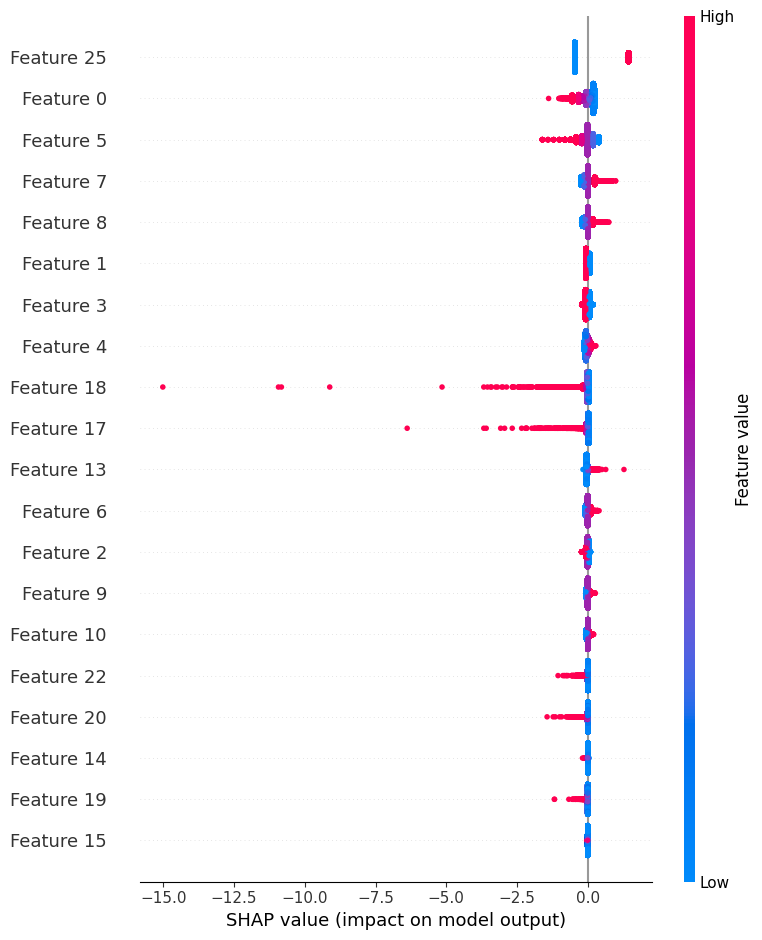

In [22]:
print(pipeline.named_steps)

import shap

# Apply preprocessing steps in order
X_train_transformed = pipeline.named_steps["feature_engineering"].transform(X_train)
X_train_transformed = pipeline.named_steps["imputer"].transform(X_train_transformed)
X_train_transformed = pipeline.named_steps["scaler"].transform(X_train_transformed)

# Extract model
model = pipeline.named_steps["model"]

# Create explainer
explainer = shap.LinearExplainer(model, X_train_transformed)

# Compute SHAP values
shap_values = explainer(X_train_transformed)

# Plot
shap.summary_plot(shap_values, X_train_transformed)